In [1]:
%matplotlib inline

import re
import warnings
from pathlib import Path
from datetime import datetime, timezone, timedelta

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

In [2]:
EVENTS_ROOT = Path('/root/autodl-tmp/Test_on_Event/menyuan')
EVENT_NAMES = ['Menyuan']

GRID_SIZE  = 150
RESOLUTION = 0.01
TOTAL_DUR  = 40.0

SUBFAULT_SIZE_KM = 2.0
SLIP_RATIO       = 0.10

V_S_KM_S               = 3.5
FAULT_LENGTH_A          = 0.50
FAULT_LENGTH_B          = -1.80
RUPTURE_VELOCITY_KM_S   = 3.0
MIN_RUPTURE_DURATION_S  = 4.0
MAX_RUPTURE_DURATION_S  = 40.0
PHYSICAL_END_BUFFER_S   = 4.0

FILTER_TO_EFFECTIVE_END       = True
MIN_TV_GT_COVERAGE            = 0.001
REPRESENTATIVE_TIME_FRACTIONS = [0.25, 0.50, 0.75, 1.0]

MANUAL_ORIGIN_TIMES = {
    'Menyuan': '2022-01-07T17:45:30+00:00',
}

ASSUME_CST_FOR_NAIVE_TIME = True

EVENT_RUPTURE_DURATION_OVERRIDES_S = {}
EVENT_EFFECTIVE_END_OVERRIDES_S    = {}

In [3]:
CST = timezone(timedelta(hours=8))


def parse_event_time(value, assume_cst=False):
    if value is None:
        return None
    text = value.decode('utf-8') if isinstance(value, (bytes, np.bytes_)) else str(value)
    text = text.strip().replace('Z', '+00:00')
    if not text or text == 'UNKNOWN':
        return None
    try:
        dt = datetime.fromisoformat(text)
    except ValueError:
        return None
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=CST if assume_cst else timezone.utc)
    return dt


def resolve_origin_time(event_name, h5_origin_value, manual_times=None):
    # origin time is always UTC
    if manual_times is not None and event_name in manual_times:
        return parse_event_time(manual_times[event_name], assume_cst=False)
    return parse_event_time(h5_origin_value, assume_cst=False)


def magnitude_to_fault_length_km(mw):
    return float(10.0 ** (FAULT_LENGTH_A * float(mw) + FAULT_LENGTH_B))


def estimate_rupture_duration_s(mw, event_name=None, overrides=None):
    if overrides is not None and event_name in overrides:
        return float(overrides[event_name])
    length_km = magnitude_to_fault_length_km(mw)
    return float(np.clip(length_km / max(float(RUPTURE_VELOCITY_KM_S), 1e-6),
                          MIN_RUPTURE_DURATION_S, MAX_RUPTURE_DURATION_S))


def estimate_t_first_trigger(eq_dep_km, eq_lat, eq_lon,
                              lons_sta=None, lats_sta=None, v_s=V_S_KM_S):
    if lons_sta is not None and lats_sta is not None and len(lons_sta) > 0:
        m_lat = 111.32
        m_lon = 111.32 * np.cos(np.radians(eq_lat))
        dx      = (np.asarray(lons_sta, dtype=np.float32) - eq_lon) * m_lon
        dy      = (np.asarray(lats_sta, dtype=np.float32) - eq_lat) * m_lat
        r_total = np.sqrt(dx**2 + dy**2 + float(eq_dep_km)**2)
        return float(r_total.min()) / max(float(v_s), 1e-6)
    return float(eq_dep_km) / max(float(v_s), 1e-6)


def representative_indices_from_mask(mask, fractions):
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return []
    out = []
    for r in fractions:
        j = int(round((len(idx) - 1) * float(r)))
        out.append(int(idx[max(0, min(len(idx)-1, j))]))
    return sorted(set(out))

In [4]:
def _next_data_line(lines, start_idx):
    for j in range(start_idx + 1, min(start_idx + 6, len(lines))):
        s = lines[j].strip()
        if s and not s.startswith('#'):
            return s.split()
    return None


def parse_pku_finite_fault(filepath):
    with open(filepath, encoding='utf-8') as f:
        lines = f.readlines()

    model_info = {}
    records    = []
    in_rupture = False

    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if 'Rupture Model' in line:
            in_rupture = True
            i += 1; continue

        if not in_rupture:
            if 'Origin_time' in line:
                model_info['origin_time'] = line.split(':', 1)[1].strip()
            elif 'Earthquake hypocenter' in line:
                vals = _next_data_line(lines, i)
                if vals:
                    model_info['hypo_lat']    = float(vals[0])
                    model_info['hypo_lon']    = float(vals[1])
                    model_info['hypo_dep_km'] = float(vals[2])
            elif 'Focal mechanism' in line:
                vals = _next_data_line(lines, i)
                if vals:
                    model_info['strike'] = float(vals[0])
                    model_info['dip']    = float(vals[1])
                    model_info['rake']   = float(vals[2])
            elif 'Number of sub_faults' in line:
                vals = _next_data_line(lines, i)
                if vals:
                    model_info['n_dip']    = int(vals[0])
                    model_info['n_strike'] = int(vals[1])
            elif 'Subfault size' in line:
                vals = _next_data_line(lines, i)
                if vals:
                    model_info['size_dip_km']    = float(vals[0])
                    model_info['size_strike_km'] = float(vals[1])
            elif 'Seismic_moment' in line:
                vals = _next_data_line(lines, i)
                if vals:
                    model_info['seismic_moment_Nm'] = float(vals[0])
                    model_info['Mw']                = float(vals[1])
            elif 'Sample Rate' in line:
                nums = re.findall(r'[\d.]+', line.replace('#', ''))
                if nums:
                    model_info['sample_rate'] = float(nums[-1])
            i += 1; continue

        if line.startswith('#') or not line:
            i += 1; continue
        parts = line.split()
        if len(parts) < 9:
            i += 1; continue
        try:
            rec = {
                'lat'            : float(parts[0]),
                'lon'            : float(parts[1]),
                'dep_km'         : float(parts[2]),
                'size_dip_km'    : float(parts[3]),
                'size_strike_km' : float(parts[4]),
                'strike'         : float(parts[5]),
                'dip'            : float(parts[6]),
                'rake'           : float(parts[7]),
                'slip_m'         : float(parts[8]),
                'tw_slips'       : [float(v) for v in parts[9:]] if len(parts) > 9 else [],
            }
            records.append(rec)
        except (ValueError, IndexError):
            pass
        i += 1

    df = pd.DataFrame(records)

    n_dip    = model_info.get('n_dip', 0)
    n_strike = model_info.get('n_strike', 0)
    if n_dip > 0 and n_strike > 0 and len(df) == n_dip * n_strike:
        iy_vals, ix_vals = np.divmod(np.arange(len(df)), n_strike)
        df['ix'] = ix_vals + 1
        df['iy'] = iy_vals + 1

    dt_tw     = 1.0 / model_info.get('sample_rate', 2.0)
    ttrg_list = []
    for _, row in df.iterrows():
        tw = row.get('tw_slips', [])
        if isinstance(tw, list) and len(tw) > 0:
            arr = np.array(tw, dtype=np.float32)
            nz  = np.where(arr > 0)[0]
            ttrg_list.append(float(nz[0]) * dt_tw if len(nz) > 0 else np.inf)
        else:
            ttrg_list.append(np.inf)
    df['ttrg_s'] = ttrg_list

    return df, model_info


def subfault_to_mask(df, eq_lat, eq_lon,
                     grid_size=GRID_SIZE, resolution=RESOLUTION,
                     slip_ratio=SLIP_RATIO):
    half      = grid_size * resolution * 0.5
    lon_min   = eq_lon - half;  lon_max = eq_lon + half
    lat_min   = eq_lat - half;  lat_max = eq_lat + half
    mask_slip = np.zeros((grid_size, grid_size), dtype=np.float32)

    if df.empty:
        return mask_slip.astype(np.uint8), mask_slip, df.copy()

    slip_max = float(df['slip_m'].max())
    if slip_max <= 0:
        return mask_slip.astype(np.uint8), mask_slip, df.iloc[0:0].copy()

    df_active = df[df['slip_m'] >= slip_max * slip_ratio].copy()
    dpx_lon   = (lon_max - lon_min) / (grid_size - 1)
    dpx_lat   = (lat_max - lat_min) / (grid_size - 1)
    m_lat     = 111.32
    m_lon     = 111.32 * np.cos(np.radians(eq_lat))
    default_size = SUBFAULT_SIZE_KM

    for _, row in df_active.iterrows():
        col_f  = (row['lon'] - lon_min) / (lon_max - lon_min) * (grid_size - 1)
        row_f  = (row['lat'] - lat_min) / (lat_max - lat_min) * (grid_size - 1)
        lx_km  = row.get('size_strike_km', default_size)
        ly_km  = row.get('size_dip_km',    default_size)
        rx_pix = (lx_km / m_lon) / dpx_lon * 0.5
        ry_pix = (ly_km / m_lat) / dpx_lat * 0.5
        c0 = max(0, int(np.floor(col_f - rx_pix)))
        c1 = min(grid_size - 1, int(np.ceil(col_f + rx_pix)))
        r0 = max(0, int(np.floor(row_f - ry_pix)))
        r1 = min(grid_size - 1, int(np.ceil(row_f + ry_pix)))
        mask_slip[r0:r1+1, c0:c1+1] = np.maximum(
            mask_slip[r0:r1+1, c0:c1+1], row['slip_m'] / slip_max)

    return (mask_slip > 0).astype(np.uint8), mask_slip, df_active


def build_time_varying_gt(df, t_inference, t_first_trigger_s,
                           eq_lat, eq_lon,
                           grid_size=GRID_SIZE, resolution=RESOLUTION,
                           slip_ratio=SLIP_RATIO):
    if df.empty:
        return np.zeros((grid_size, grid_size), dtype=np.uint8), 0

    slip_max = float(df['slip_m'].max())
    if slip_max <= 0:
        return np.zeros((grid_size, grid_size), dtype=np.uint8), 0

    t_origin  = float(t_inference) + float(t_first_trigger_s)
    df_active = df[
        (df['ttrg_s'] <= t_origin) &
        (df['slip_m'] >= slip_max * slip_ratio)
    ].copy()

    if df_active.empty:
        return np.zeros((grid_size, grid_size), dtype=np.uint8), 0

    half      = grid_size * resolution * 0.5
    lon_min   = eq_lon - half;  lon_max = eq_lon + half
    lat_min   = eq_lat - half;  lat_max = eq_lat + half
    mask_slip = np.zeros((grid_size, grid_size), dtype=np.float32)
    dpx_lon   = (lon_max - lon_min) / (grid_size - 1)
    dpx_lat   = (lat_max - lat_min) / (grid_size - 1)
    m_lat     = 111.32
    m_lon     = 111.32 * np.cos(np.radians(eq_lat))
    default_size = SUBFAULT_SIZE_KM

    for _, row in df_active.iterrows():
        col_f  = (row['lon'] - lon_min) / (lon_max - lon_min) * (grid_size - 1)
        row_f  = (row['lat'] - lat_min) / (lat_max - lat_min) * (grid_size - 1)
        lx_km  = row.get('size_strike_km', default_size)
        ly_km  = row.get('size_dip_km',    default_size)
        rx_pix = (lx_km / m_lon) / dpx_lon * 0.5
        ry_pix = (ly_km / m_lat) / dpx_lat * 0.5
        c0 = max(0, int(np.floor(col_f - rx_pix)))
        c1 = min(grid_size - 1, int(np.ceil(col_f + rx_pix)))
        r0 = max(0, int(np.floor(row_f - ry_pix)))
        r1 = min(grid_size - 1, int(np.ceil(row_f + ry_pix)))
        mask_slip[r0:r1+1, c0:c1+1] = np.maximum(
            mask_slip[r0:r1+1, c0:c1+1], row['slip_m'] / slip_max)

    return (mask_slip > 0).astype(np.uint8), len(df_active)

In [5]:
def compute_metrics(pred, gt):
    pred = pred.astype(bool).flatten()
    gt   = gt.astype(bool).flatten()
    tp   = int((pred & gt).sum())
    fp   = int((pred & ~gt).sum())
    fn   = int((~pred & gt).sum())
    tn   = int((~pred & ~gt).sum())
    return {
        'IoU'      : float(tp / (tp + fp + fn + 1e-8)),
        'F1/Dice'  : float(2 * tp / (2 * tp + fp + fn + 1e-8)),
        'Precision': float(tp / (tp + fp + 1e-8)),
        'Recall'   : float(tp / (tp + fn + 1e-8)),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
    }


def get_event_metadata(event_dir, event_name, df_gt, info_gt):
    meta_path = event_dir / 'event_metadata.npz'

    if meta_path.exists():
        meta = np.load(meta_path, allow_pickle=True)

        eq_mag             = float(meta['eq_mag'])
        eq_dep             = float(meta['eq_dep'])
        t_first_trigger_s  = float(meta['t_first_trigger_s'])
        effective_end_abs_s = float(meta['effective_end_abs_s'])

        # rupture_duration_s: saved by new inference notebook
        if 'rupture_duration_s' in meta:
            rupture_duration_s = float(meta['rupture_duration_s'])
        else:
            rupture_duration_s = estimate_rupture_duration_s(
                eq_mag, event_name=event_name,
                overrides=EVENT_RUPTURE_DURATION_OVERRIDES_S)

        # effective_end_inf_s: saved by new inference notebook
        if 'effective_end_inf_s' in meta:
            effective_end_inf_s = float(meta['effective_end_inf_s'])
        else:
            effective_end_inf_s = max(
                0.0, effective_end_abs_s - t_first_trigger_s)

        return {
            'eq_lat'              : float(meta['eq_lat']),
            'eq_lon'              : float(meta['eq_lon']),
            'eq_mag'              : eq_mag,
            'eq_dep'              : eq_dep,
            'rupture_duration_s'  : rupture_duration_s,
            'effective_end_abs_s' : effective_end_abs_s,
            'effective_end_inf_s' : effective_end_inf_s,
            't_first_trigger_s'   : t_first_trigger_s,
            'source'              : 'event_metadata.npz',
        }

    # fallback: recompute from H5
    h5_files   = list(event_dir.glob('*.h5'))
    lons_sta, lats_sta = [], []

    if h5_files:
        with h5py.File(h5_files[0], 'r') as f:
            eq     = f['earthquake']
            eq_lat = float(eq.attrs['latitude'])
            eq_lon = float(eq.attrs['longitude'])
            eq_mag = float(eq.attrs.get('magnitude', info_gt.get('Mw', 0.0)))
            eq_dep = float(eq.attrs.get('depth', 10.0))
            if 'stations' in f:
                half = GRID_SIZE * RESOLUTION * 0.5
                for sid in f['stations'].keys():
                    g  = f['stations'][sid]
                    lo = float(g.attrs.get('longitude', 0.0))
                    la = float(g.attrs.get('latitude',  0.0))
                    if (eq_lon - half <= lo <= eq_lon + half and
                            eq_lat - half <= la <= eq_lat + half):
                        lons_sta.append(lo)
                        lats_sta.append(la)
    else:
        eq_lat = float(info_gt.get('hypo_lat', df_gt['lat'].mean()))
        eq_lon = float(info_gt.get('hypo_lon', df_gt['lon'].mean()))
        eq_mag = float(info_gt.get('Mw', 0.0))
        eq_dep = float(info_gt.get('hypo_dep_km', 10.0))

    t_first_trigger_s  = estimate_t_first_trigger(
        eq_dep, eq_lat, eq_lon,
        lons_sta if lons_sta else None,
        lats_sta if lats_sta else None,
        v_s=V_S_KM_S)
    rupture_duration_s  = estimate_rupture_duration_s(
        eq_mag, event_name=event_name,
        overrides=EVENT_RUPTURE_DURATION_OVERRIDES_S)
    effective_end_abs_s = EVENT_EFFECTIVE_END_OVERRIDES_S.get(
        event_name, rupture_duration_s + PHYSICAL_END_BUFFER_S)
    effective_end_inf_s = max(
        0.0, float(effective_end_abs_s) - float(t_first_trigger_s))

    return {
        'eq_lat': eq_lat, 'eq_lon': eq_lon,
        'eq_mag': eq_mag, 'eq_dep': eq_dep,
        'rupture_duration_s' : rupture_duration_s,
        'effective_end_abs_s': effective_end_abs_s,
        'effective_end_inf_s': effective_end_inf_s,
        't_first_trigger_s'  : t_first_trigger_s,
        'source': 'fallback',
    }


def safe_load_prediction(event_dir):
    pred_path = event_dir / 'pred_binary.npy'
    if not pred_path.exists():
        return None, None, None
    pred_binary  = np.load(pred_path)
    sliding_path = event_dir / 'pred_sliding_vote.npy'
    pred_sliding = np.load(sliding_path) if sliding_path.exists() else None
    t_path  = event_dir / 'times_mid_valid.npy'
    t_axis  = (np.load(t_path) if t_path.exists()
               else np.arange(pred_binary.shape[0], dtype=np.float32))
    if len(t_axis) != pred_binary.shape[0]:
        t_axis = np.arange(pred_binary.shape[0], dtype=np.float32)
    return pred_binary, pred_sliding, t_axis.astype(np.float32)

In [6]:
def overlap_rgb(pred, gt):
    pred, gt = pred.astype(bool), gt.astype(bool)
    img = np.zeros((*pred.shape, 3), dtype=np.uint8)
    img[pred & gt]   = [80, 200, 80]
    img[pred & ~gt]  = [220, 60, 60]
    img[~pred & gt]  = [60, 120, 220]
    img[~pred & ~gt] = [30, 30, 30]
    return img


def add_overlap_legend(ax):
    handles = [
        plt.Line2D([0],[0], marker='s', linestyle='', markersize=8,
                   markerfacecolor=np.array([80,200,80])/255,
                   markeredgecolor='none', label='TP'),
        plt.Line2D([0],[0], marker='s', linestyle='', markersize=8,
                   markerfacecolor=np.array([220,60,60])/255,
                   markeredgecolor='none', label='FP'),
        plt.Line2D([0],[0], marker='s', linestyle='', markersize=8,
                   markerfacecolor=np.array([60,120,220])/255,
                   markeredgecolor='none', label='FN'),
        plt.Line2D([0],[0], marker='s', linestyle='', markersize=8,
                   markerfacecolor=np.array([30,30,30])/255,
                   markeredgecolor='none', label='TN'),
    ]
    ax.legend(handles=handles, loc='lower right', fontsize=8, framealpha=0.8)


def plot_static_visual_comparison(event_dir, event_name, pred_final, mask_gt_bin):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), squeeze=False)
    axes[0,0].imshow(mask_gt_bin, origin='lower', cmap='gray')
    axes[0,0].set_title('PKU static GT'); axes[0,0].axis('off')
    axes[0,1].imshow(pred_final, origin='lower', cmap='gray')
    axes[0,1].set_title('Prediction final'); axes[0,1].axis('off')
    axes[0,2].imshow(overlap_rgb(pred_final, mask_gt_bin), origin='lower')
    axes[0,2].set_title('Prediction vs PKU'); axes[0,2].axis('off')
    add_overlap_legend(axes[0,2])
    plt.suptitle(f'{event_name} — Static GT visual comparison', y=1.01)
    plt.tight_layout()
    plt.savefig(event_dir / f'{event_name}_static_visual_comparison.png',
                dpi=150, bbox_inches='tight')
    plt.show()


def plot_time_varying_visual_comparison(
        event_dir, event_name,
        t_axis, pred_binary, pred_sliding,
        df_gt, eq_lat, eq_lon,
        t_first_trigger_s, frame_indices):
    if not frame_indices:
        return
    pred_source = pred_sliding if pred_sliding is not None else pred_binary
    n   = len(frame_indices)
    fig, axes = plt.subplots(3, n, figsize=(3*n, 9), squeeze=False)
    for j, idx in enumerate(frame_indices):
        t_inf = float(t_axis[idx])
        gt_t, _ = build_time_varying_gt(
            df_gt, t_inf, t_first_trigger_s, eq_lat, eq_lon)
        pred_t = pred_source[idx]
        axes[0,j].imshow(pred_t, origin='lower', cmap='gray')
        axes[0,j].set_title(f'Pred t={t_inf:.1f}s'); axes[0,j].axis('off')
        axes[1,j].imshow(gt_t, origin='lower', cmap='gray')
        axes[1,j].set_title('PKU TV-GT'); axes[1,j].axis('off')
        axes[2,j].imshow(overlap_rgb(pred_t, gt_t), origin='lower')
        axes[2,j].set_title('Pred vs PKU'); axes[2,j].axis('off')
        if j == n - 1:
            add_overlap_legend(axes[2,j])
    plt.suptitle(f'{event_name} — Time-varying GT visual comparison', y=1.005)
    plt.tight_layout()
    plt.savefig(
        event_dir / f'{event_name}_time_varying_visual_comparison.png',
        dpi=150, bbox_inches='tight')
    plt.show()


def plot_temporal_iou(
        event_dir, event_name,
        t_axis, pred_binary, pred_sliding,
        mask_gt_bin, pred_final,
        tv_iou, tv_iou_sliding,
        effective_end_inf_s):
    T = pred_binary.shape[0]
    iou_static = np.asarray(
        [compute_metrics(pred_binary[t], mask_gt_bin)['IoU'] for t in range(T)],
        dtype=np.float32)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t_axis, iou_static,
            label=f'Static GT  max={np.nanmax(iou_static):.3f}',
            linewidth=1.5)
    ax.plot(t_axis, tv_iou,
            label=f'TV-GT  max={np.nanmax(tv_iou):.3f}',
            linewidth=2.0, linestyle='--')
    if pred_sliding is not None:
        iou_sl_static = np.asarray(
            [compute_metrics(pred_sliding[t], mask_gt_bin)['IoU']
             for t in range(T)], dtype=np.float32)
        ax.plot(t_axis, iou_sl_static,
                label=f'Sliding vs Static  max={np.nanmax(iou_sl_static):.3f}',
                linewidth=1.5, linestyle=':')
        ax.plot(t_axis, tv_iou_sliding,
                label=f'Sliding vs TV  max={np.nanmax(tv_iou_sliding):.3f}',
                linewidth=2.0, linestyle='-.')
    ax.axhline(
        compute_metrics(pred_final, mask_gt_bin)['IoU'],
        linewidth=1.0, linestyle=':',
        label='Final committed vs Static')
    ax.axvline(
        effective_end_inf_s, linewidth=1.2, linestyle='--',
        label=f'Effective end={effective_end_inf_s:.1f}s')
    if FILTER_TO_EFFECTIVE_END and len(t_axis) > 0:
        ax.axvspan(effective_end_inf_s, float(t_axis.max()), alpha=0.15)
    ax.set_xlabel('Time relative to first trigger (s)')
    ax.set_ylabel('IoU')
    ax.set_title(f'{event_name} — Temporal IoU (PKU GT)')
    ax.legend(fontsize=8)
    ax.grid(lw=0.4, alpha=0.4)
    plt.tight_layout()
    plt.savefig(event_dir / f'{event_name}_temporal_iou.png',
                dpi=150, bbox_inches='tight')
    plt.show()


Event: Menyuan
/root/autodl-tmp/Test_on_Event/menyuan/Menyuan
  GT subfaults: 99  Mw=6.5
  metadata source: event_metadata.npz
  eq: M6.900000095367432 dep=10.0km  eff_end=15.3s  t_first=3.6s
  static GT pixels: 105
  Static  IoU=0.113  F1=0.204  Prec=0.118  Rec=0.762
  TV-GT   max IoU=0.365  at t=8.8s


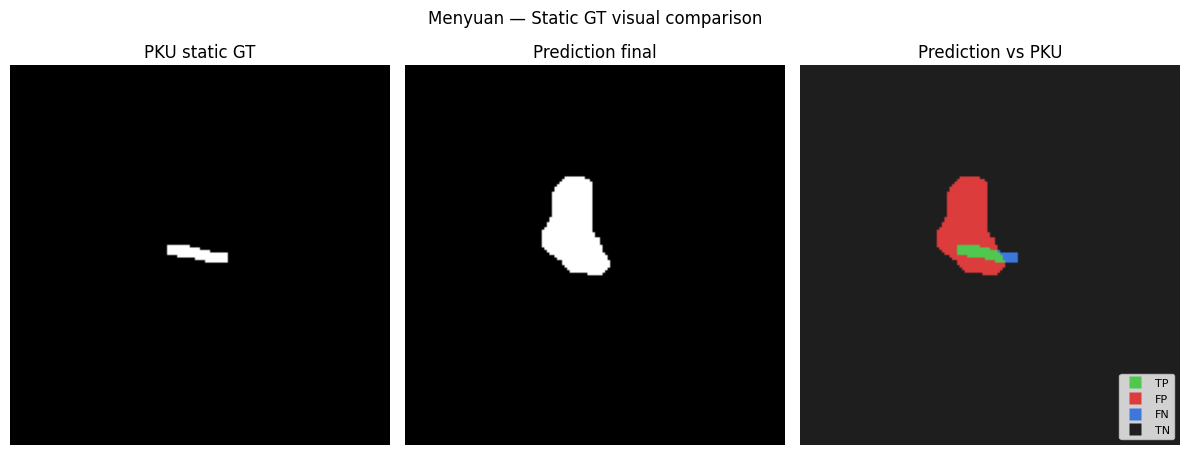

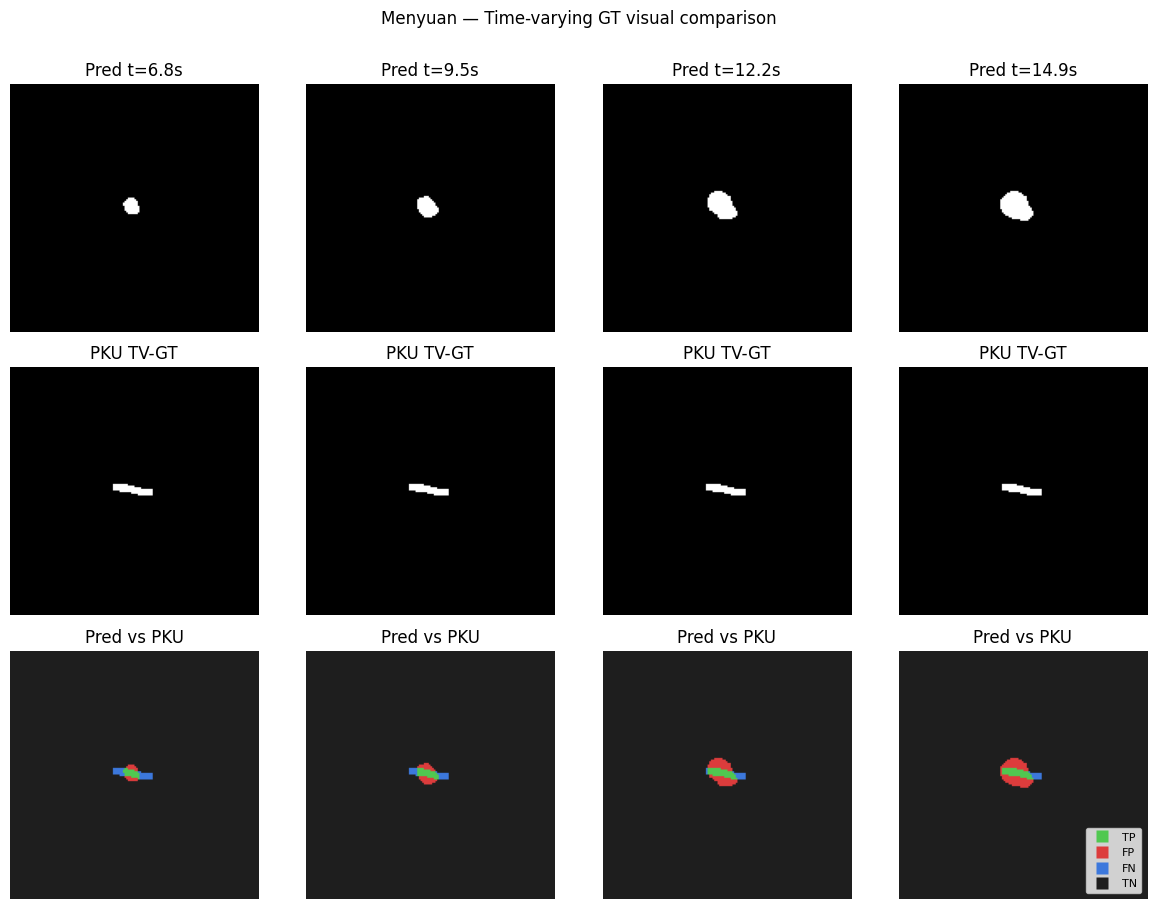

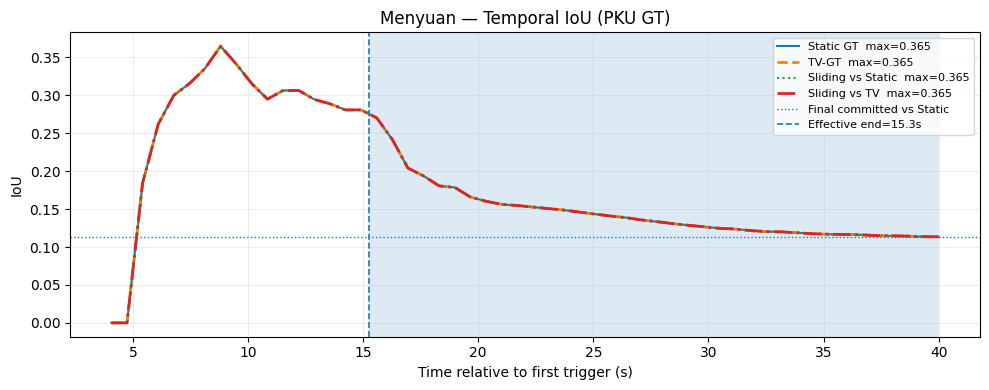


  event  eq_mag  static_IoU  static_F1  static_Precision  static_Recall  static_TP  static_FP  static_FN  tv_max_IoU  tv_best_t  effective_end_inf_s  t_first_trigger_s                                 gt_file  gt_n_subfaults  gt_n_active
Menyuan     6.9    0.113475   0.203822          0.117647       0.761905         80        600         25     0.36478    8.81356            15.274853             3.6146 20220107174530_Menyuan_Rupture_Info.txt              99          105

Saved: menyuan_compare_results.csv


In [7]:
all_results = []

for event_name in EVENT_NAMES:
    event_dir = EVENTS_ROOT / event_name
    print(f'\n{'='*60}')
    print(f'Event: {event_name}')
    print(event_dir)

    # locate PKU finite fault file
    ff_files = (list(event_dir.glob('*.fsp')) +
                list(event_dir.glob('*.txt')) +
                list(event_dir.glob('*.dat')))
    # ff_files = [p for p in ff_files if 'pku' in p.name.lower()
    #             or 'finite' in p.name.lower() or 'fault' in p.name.lower()]
    if not ff_files:
        print(f'  [SKIP] no PKU finite fault file found in {event_dir}')
        continue

    df_gt, info_gt = parse_pku_finite_fault(str(ff_files[0]))
    print(f'  GT subfaults: {len(df_gt)}  '
          f'Mw={info_gt.get("Mw", "?")}')

    pred_binary, pred_sliding, t_axis = safe_load_prediction(event_dir)
    if pred_binary is None:
        print(f'  [SKIP] no prediction found')
        continue

    meta = get_event_metadata(event_dir, event_name, df_gt, info_gt)
    print(f'  metadata source: {meta["source"]}')
    print(f'  eq: M{meta["eq_mag"]} dep={meta["eq_dep"]}km  '
          f'eff_end={meta["effective_end_inf_s"]:.1f}s  '
          f't_first={meta["t_first_trigger_s"]:.1f}s')

    eq_lat, eq_lon           = meta['eq_lat'], meta['eq_lon']
    t_first_trigger_s        = meta['t_first_trigger_s']
    effective_end_inf_s      = meta['effective_end_inf_s']

    # static GT mask
    mask_gt_bin, _, df_active = subfault_to_mask(df_gt, eq_lat, eq_lon)
    print(f'  static GT pixels: {mask_gt_bin.sum()}')

    # final committed frame
    pred_final = pred_binary[-1]

    # static metrics
    static_m = compute_metrics(pred_final, mask_gt_bin)
    print(f'  Static  IoU={static_m["IoU"]:.3f}  '
          f'F1={static_m["F1/Dice"]:.3f}  '
          f'Prec={static_m["Precision"]:.3f}  '
          f'Rec={static_m["Recall"]:.3f}')

    # time-varying IoU
    T          = pred_binary.shape[0]
    end_mask   = (t_axis <= effective_end_inf_s) if FILTER_TO_EFFECTIVE_END \
                 else np.ones(T, dtype=bool)

    tv_iou         = np.full(T, np.nan, dtype=np.float32)
    tv_iou_sliding = np.full(T, np.nan, dtype=np.float32)

    for t in range(T):
        gt_t, n_active = build_time_varying_gt(
            df_gt, float(t_axis[t]), t_first_trigger_s, eq_lat, eq_lon)
        if n_active / max(len(df_gt), 1) >= MIN_TV_GT_COVERAGE:
            tv_iou[t] = compute_metrics(pred_binary[t], gt_t)['IoU']
            if pred_sliding is not None:
                tv_iou_sliding[t] = compute_metrics(
                    pred_sliding[t], gt_t)['IoU']

    valid_tv = tv_iou[end_mask & np.isfinite(tv_iou)]
    if len(valid_tv) > 0:
        best_idx = int(np.nanargmax(tv_iou * end_mask.astype(float)))
        print(f'  TV-GT   max IoU={float(np.nanmax(valid_tv)):.3f}  '
              f'at t={t_axis[best_idx]:.1f}s')

    # representative frames for visual comparison
    rep_frames = representative_indices_from_mask(
        end_mask, REPRESENTATIVE_TIME_FRACTIONS)

    plot_static_visual_comparison(
        event_dir, event_name, pred_final, mask_gt_bin)
    plot_time_varying_visual_comparison(
        event_dir, event_name,
        t_axis, pred_binary, pred_sliding,
        df_gt, eq_lat, eq_lon,
        t_first_trigger_s, rep_frames)
    plot_temporal_iou(
        event_dir, event_name,
        t_axis, pred_binary, pred_sliding,
        mask_gt_bin, pred_final,
        tv_iou, tv_iou_sliding,
        effective_end_inf_s)

    all_results.append({
        'event'              : event_name,
        'eq_mag'             : meta['eq_mag'],
        'static_IoU'         : static_m['IoU'],
        'static_F1'          : static_m['F1/Dice'],
        'static_Precision'   : static_m['Precision'],
        'static_Recall'      : static_m['Recall'],
        'static_TP'          : static_m['TP'],
        'static_FP'          : static_m['FP'],
        'static_FN'          : static_m['FN'],
        'tv_max_IoU'         : float(np.nanmax(tv_iou)) if np.any(np.isfinite(tv_iou)) else np.nan,
        'tv_best_t'          : float(t_axis[int(np.nanargmax(tv_iou))]) if np.any(np.isfinite(tv_iou)) else np.nan,
        'effective_end_inf_s': effective_end_inf_s,
        't_first_trigger_s'  : t_first_trigger_s,
        'gt_file'            : str(ff_files[0].name),
        'gt_n_subfaults'     : len(df_gt),
        'gt_n_active'        : int(mask_gt_bin.sum()),
    })

if all_results:
    df_out = pd.DataFrame(all_results)
    print(f'\n{df_out.to_string(index=False)}')
    df_out.to_csv(EVENTS_ROOT / 'menyuan_compare_results.csv', index=False)
    print('\nSaved: menyuan_compare_results.csv')